# Final Project Results

## GCN Baseline

In [14]:
import sys
from pathlib import Path

# Allows importing from the project root
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(project_root))


Imports

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.gcn_baseline import run_experiment


Pick dataset

In [16]:
dataset_name = "Cora"  # "CiteSeer" or "Cora"

if dataset_name.lower() == "citeseer":
    dataset_name = "CiteSeer"

dataset_name


'Cora'

Run the GCN experiment

In [17]:
model, dataset, data, results = run_experiment(dataset_name, epochs=200)

run_path = Path(results["run_dir"])
plot_path = Path(results["plot_dir"])
losses = results["losses"]
val_accuracies = results["val_accuracies"]

model


Dataset: Cora
Nodes: 2708
Edges: 10556
Features per node: 1433
Classes: 7
Train nodes: 140
Validation nodes: 500
Test nodes: 1000
Epoch: 1 Loss: 1.9458 Val acc: 0.168
Epoch: 20 Loss: 1.719 Val acc: 0.696
Epoch: 40 Loss: 1.329 Val acc: 0.724
Epoch: 60 Loss: 0.8978 Val acc: 0.76
Epoch: 80 Loss: 0.6774 Val acc: 0.77
Epoch: 100 Loss: 0.5285 Val acc: 0.774
Epoch: 120 Loss: 0.4904 Val acc: 0.776
Epoch: 140 Loss: 0.4242 Val acc: 0.772
Epoch: 160 Loss: 0.3845 Val acc: 0.772
Epoch: 180 Loss: 0.3446 Val acc: 0.782
Epoch: 200 Loss: 0.33 Val acc: 0.774

Final results:
Train accuracy: 0.9929
Validation accuracy: 0.774
Test accuracy: 0.794
Macro F1: 0.7848
Weighted F1: 0.7956
Saved run to: /Users/davidgarzon/Documents/UCF/MAAI/Project/EEL6878_Final_Project/results/runs/gcn/20260504_014635_Cora_GCN
Plots go to: /Users/davidgarzon/Documents/UCF/MAAI/Project/EEL6878_Final_Project/results/plots/gcn/20260504_014635_Cora_GCN


GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)

Tables

In [18]:
dataset_table = pd.DataFrame([
    {
        "Dataset": dataset.name,
        "Nodes": data.num_nodes,
        "Edges": data.num_edges,
        "Avg Degree": data.num_edges / data.num_nodes,
        "Density": data.num_edges / (data.num_nodes * (data.num_nodes - 1)),
        "Features": dataset.num_node_features,
        "Classes": dataset.num_classes,
        "Train": int(data.train_mask.sum()),
        "Val": int(data.val_mask.sum()),
        "Test": int(data.test_mask.sum()),
    }
])

main_results_table = pd.DataFrame([
    {
        "Dataset": dataset.name,
        "Model": "GCN",
        "Train Acc": results["train_acc"],
        "Val Acc": results["val_acc"],
        "Test Acc": results["test_acc"],
        "Macro F1": results["macro_f1"],
        "Weighted F1": results["weighted_f1"],
    }
])

model_table = pd.DataFrame([
    {
        "Model": "GCN",
        "Hidden Size": 16,
        "Epochs": 200,
        "Learning Rate": 0.01,
        "Weight Decay": 0.0005,
        "Parameters": results["parameters"],
    }
])

print("Dataset Table")
display(dataset_table.round(4))

print("Main Results Table")
display(main_results_table.round(4))

print("Model Table")
display(model_table)

print("Run folder:", run_path)
print("Plot folder:", plot_path)


Dataset Table


,Dataset,Nodes,Edges,Avg Degree,Density,Features,Classes,Train,Val,Test
0,Cora,2708,10556,3.8981,0.0014,1433,7,140,500,1000


Main Results Table


,Dataset,Model,Train Acc,Val Acc,Test Acc,Macro F1,Weighted F1
0,Cora,GCN,0.9929,0.774,0.794,0.7848,0.7956


Model Table


,Model,Hidden Size,Epochs,Learning Rate,Weight Decay,Parameters
0,GCN,16,200,0.01,0.0005,23063


Run folder: /Users/davidgarzon/Documents/UCF/MAAI/Project/EEL6878_Final_Project/results/runs/gcn/20260504_014635_Cora_GCN
Plot folder: /Users/davidgarzon/Documents/UCF/MAAI/Project/EEL6878_Final_Project/results/plots/gcn/20260504_014635_Cora_GCN


Per-class metrics

In [19]:
per_class_table = pd.DataFrame(results["per_class_metrics"])

print("Per-class Test Metrics")
display(per_class_table.round(4))


Per-class Test Metrics


,class,precision,recall,f1,support
0,0,0.6709,0.8154,0.7361,130
1,1,0.7315,0.8681,0.7940,91
2,2,0.8621,0.8681,0.8651,144
3,3,0.8966,0.7335,0.8069,319
4,4,0.7716,0.8389,0.8039,149
5,5,0.8444,0.7379,0.7876,103
6,6,0.6447,0.7656,0.7000,64


Training plots

Saved: /Users/davidgarzon/Documents/UCF/MAAI/Project/EEL6878_Final_Project/results/plots/gcn/20260504_014635_Cora_GCN/training_curves.png


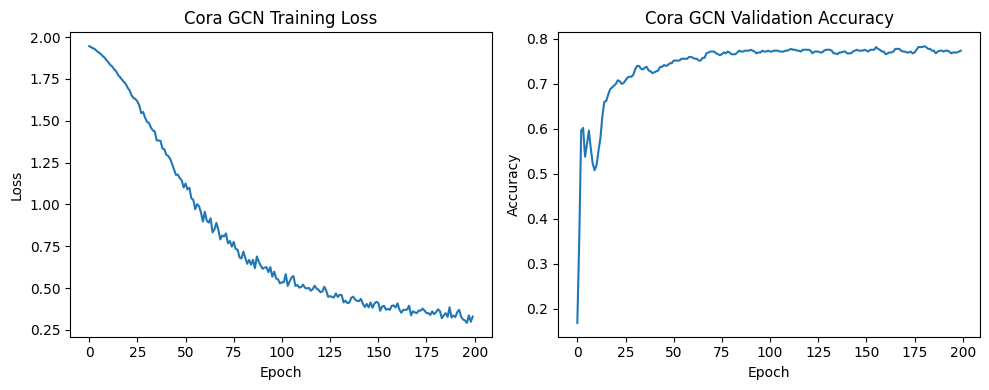

In [20]:
training_plot = plot_path / "training_curves.png"

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title(dataset_name + " GCN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(val_accuracies)
plt.title(dataset_name + " GCN Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.savefig(training_plot, dpi=150, bbox_inches="tight")
print("Saved:", training_plot)
plt.show()


Confusion matrix

Saved: /Users/davidgarzon/Documents/UCF/MAAI/Project/EEL6878_Final_Project/results/plots/gcn/20260504_014635_Cora_GCN/confusion_matrix.png


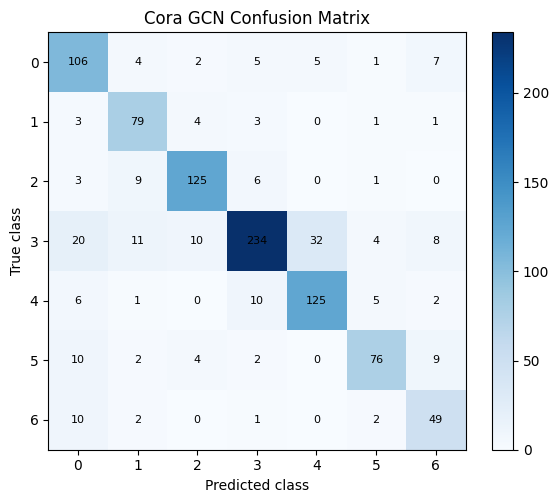

In [21]:
confusion_plot = plot_path / "confusion_matrix.png"
confusion = results["confusion_matrix"]

plt.figure(figsize=(6, 5))
plt.imshow(confusion, cmap="Blues")
plt.title(dataset_name + " GCN Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()

for i in range(len(confusion)):
    for j in range(len(confusion[i])):
        plt.text(j, i, confusion[i][j], ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(confusion_plot, dpi=150, bbox_inches="tight")
print("Saved:", confusion_plot)
plt.show()


## Graph Transformer

Run the model

In [22]:
from src.graph_transformer import run_experiment as run_transformer_experiment

model_t, dataset_t, data_t, results_t = run_transformer_experiment(dataset_name, epochs=200)

run_path_t = Path(results_t["run_dir"])
plot_path_t = Path(results_t["plot_dir"])
losses_t = results_t["losses"]
val_accuracies_t = results_t["val_accuracies"]

model_t

Dataset: Cora
Nodes: 2708
Edges: 10556
Features per node: 1433
Classes: 7
Train nodes: 140
Validation nodes: 500
Test nodes: 1000
Epoch: 001, Loss: 1.9496, Val Acc: 0.2180
Epoch: 020, Loss: 1.3461, Val Acc: 0.7700
Epoch: 040, Loss: 0.4809, Val Acc: 0.7860
Epoch: 060, Loss: 0.2070, Val Acc: 0.7780
Epoch: 080, Loss: 0.1435, Val Acc: 0.7720
Epoch: 100, Loss: 0.1224, Val Acc: 0.7700
Epoch: 120, Loss: 0.1054, Val Acc: 0.7700
Epoch: 140, Loss: 0.0937, Val Acc: 0.7680
Epoch: 160, Loss: 0.1187, Val Acc: 0.7740
Epoch: 180, Loss: 0.0816, Val Acc: 0.7580
Epoch: 200, Loss: 0.0796, Val Acc: 0.7700

Final results:
Train accuracy: 1.0
Validation accuracy: 0.77
Test accuracy: 0.792
Macro F1: 0.7868
Weighted F1: 0.7938
Saved run to: /Users/davidgarzon/Documents/UCF/MAAI/Project/EEL6878_Final_Project/results/runs/graph_transformer/20260504_014644_Cora_GraphTransformer
Plots go to: /Users/davidgarzon/Documents/UCF/MAAI/Project/EEL6878_Final_Project/results/plots/graph_transformer/20260504_014644_Cora_Gra

GraphTransformer(
  (conv1): TransformerConv(1433, 16, heads=4)
  (conv2): TransformerConv(64, 7, heads=1)
)

Display tables

In [23]:
main_results_table_t = pd.DataFrame([{
    "Dataset": dataset_t.name, "Model": "Graph Transformer", "Train Acc": results_t["train_acc"],
    "Val Acc": results_t["val_acc"], "Test Acc": results_t["test_acc"],
    "Macro F1": results_t["macro_f1"], "Weighted F1": results_t["weighted_f1"]
}])

model_table_t = pd.DataFrame([{
    "Model": "Graph Transformer", "Hidden Size": "16 (x4)", "Epochs": 200,
    "Learning Rate": 0.005, "Weight Decay": 0.0005, "Parameters": results_t["parameters"]
}])

print("Main Results Table")
display(main_results_table_t.round(4))

print("Model Table")
display(model_table_t)

print("Run folder:", run_path_t)
print("Plot folder:", plot_path_t)

Main Results Table


,Dataset,Model,Train Acc,Val Acc,Test Acc,Macro F1,Weighted F1
0,Cora,Graph Transformer,1.0,0.77,0.792,0.7868,0.7938


Model Table


,Model,Hidden Size,Epochs,Learning Rate,Weight Decay,Parameters
0,Graph Transformer,16 (x4),200,0.005,0.0005,368924


Run folder: /Users/davidgarzon/Documents/UCF/MAAI/Project/EEL6878_Final_Project/results/runs/graph_transformer/20260504_014644_Cora_GraphTransformer
Plot folder: /Users/davidgarzon/Documents/UCF/MAAI/Project/EEL6878_Final_Project/results/plots/graph_transformer/20260504_014644_Cora_GraphTransformer


Training plots

Saved: /Users/davidgarzon/Documents/UCF/MAAI/Project/EEL6878_Final_Project/results/plots/graph_transformer/20260504_014644_Cora_GraphTransformer/training_curves.png


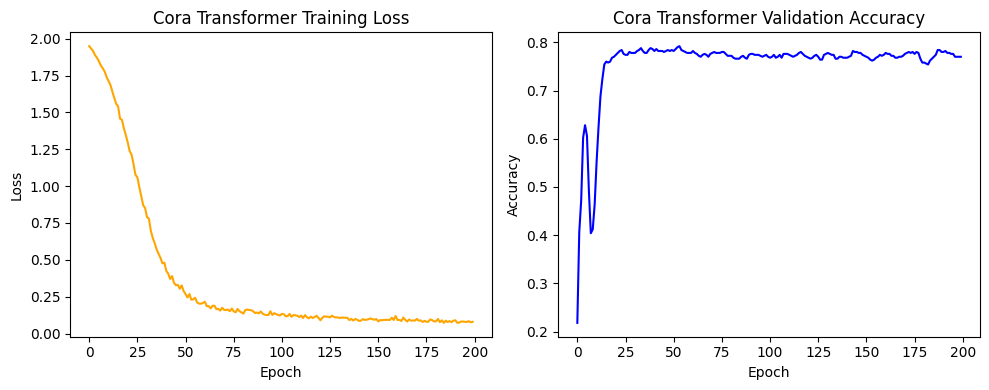

In [24]:
training_plot_t = plot_path_t / "training_curves.png"

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses_t, color='orange')
plt.title(dataset_name + " Transformer Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(val_accuracies_t, color='blue')
plt.title(dataset_name + " Transformer Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.savefig(training_plot_t, dpi=150, bbox_inches="tight")
print("Saved:", training_plot_t)
plt.show()

Confusion Matrix

Saved: /Users/davidgarzon/Documents/UCF/MAAI/Project/EEL6878_Final_Project/results/plots/graph_transformer/20260504_014644_Cora_GraphTransformer/confusion_matrix.png


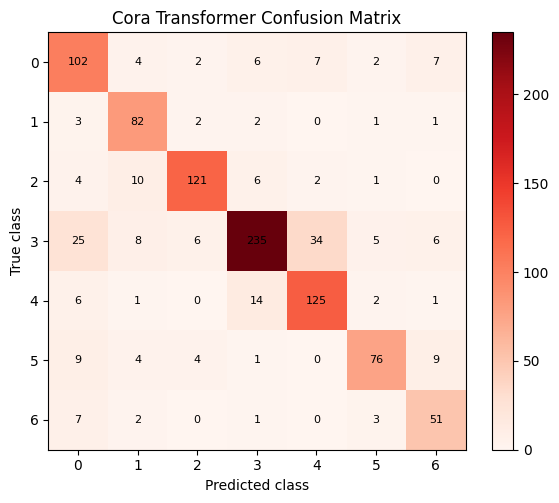

In [25]:
confusion_plot_t = plot_path_t / "confusion_matrix.png"
confusion_t = results_t["confusion_matrix"]

plt.figure(figsize=(6, 5))
plt.imshow(confusion_t, cmap="Reds")
plt.title(dataset_name + " Transformer Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()

for i in range(len(confusion_t)):
    for j in range(len(confusion_t[i])):
        plt.text(j, i, confusion_t[i][j], ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(confusion_plot_t, dpi=150, bbox_inches="tight")
print("Saved:", confusion_plot_t)
plt.show()